###  셀프-어텐션(Self-Attention) 기법
- 어텐션 기법이 입력-출력 간의 대응 관계를 확인하느냐 또는 입력 내에서 또는 출력 내에서 대응 관계를 확인하느냐
    - 기존 어텐션 기법은 입력-출력 간에 대응되는 단어 관계를 파악하는 게 핵심
    - 셀프-어텐션 기법은 입력-출력 간이 아닌 입력, 출력 각 시퀀스 내부의 단어들 간의 대응 관계를 파악

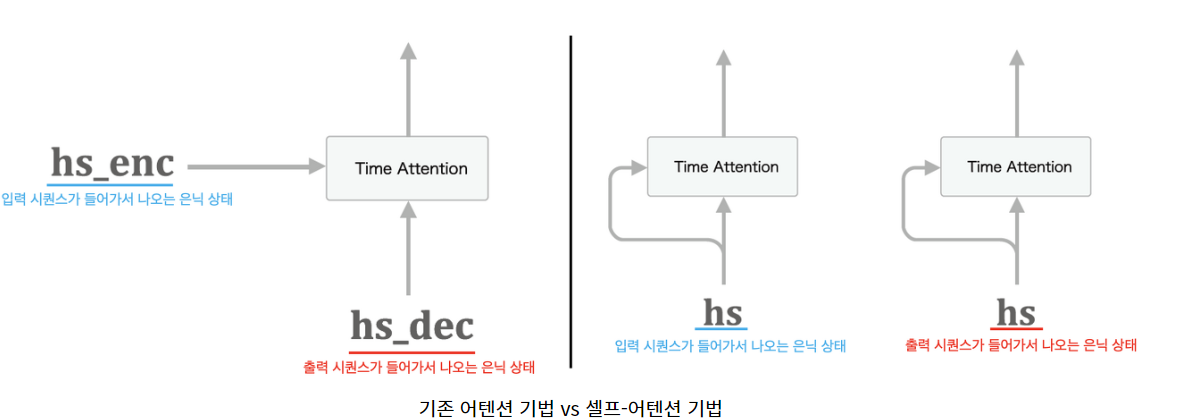

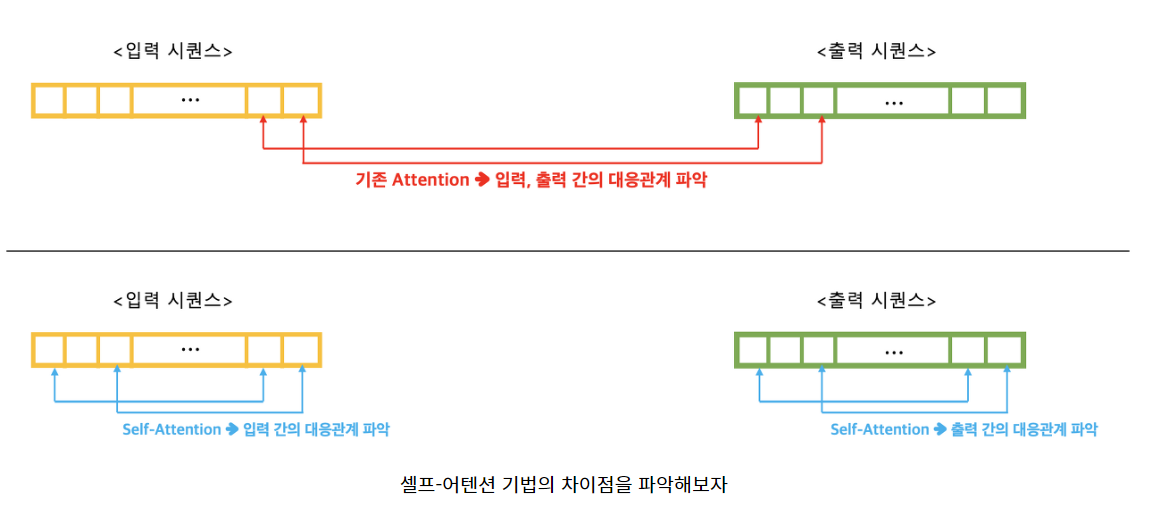

- 셀프-어텐션 기법은 입력 시퀀스 내에서의 대응관계를 학습하고 동시에 출력 시퀀스 내에서의 대응관계도 학습하는 방법
- 재귀적으로 쌓아서 기존 seq2seq 모델의 RNN이 하던 (과거의 기억을 유지하는)메모리 네트워크 역할을 대체

### 트랜스포머(Transformer)
-  2017년 구글이 발표한 논문인 "Attention is all you need"에서 나온 모델
- 기존의 seq2seq의 구조인 인코더-디코더를 따르면서도, 논문의 이름처럼 어텐션(Attention)만으로 구현한 모델
- RNN을 사용하지 않고, 인코더-디코더 구조를 설계하였음에도 번역 성능에서도 RNN보다 우수한 성능을 보여줌
- 트랜스포머 모델 구성요소
    - 셀프-어텐션,
    - Point-wise Feed-Forward Network(논문 상에서 FFN이라고 함)

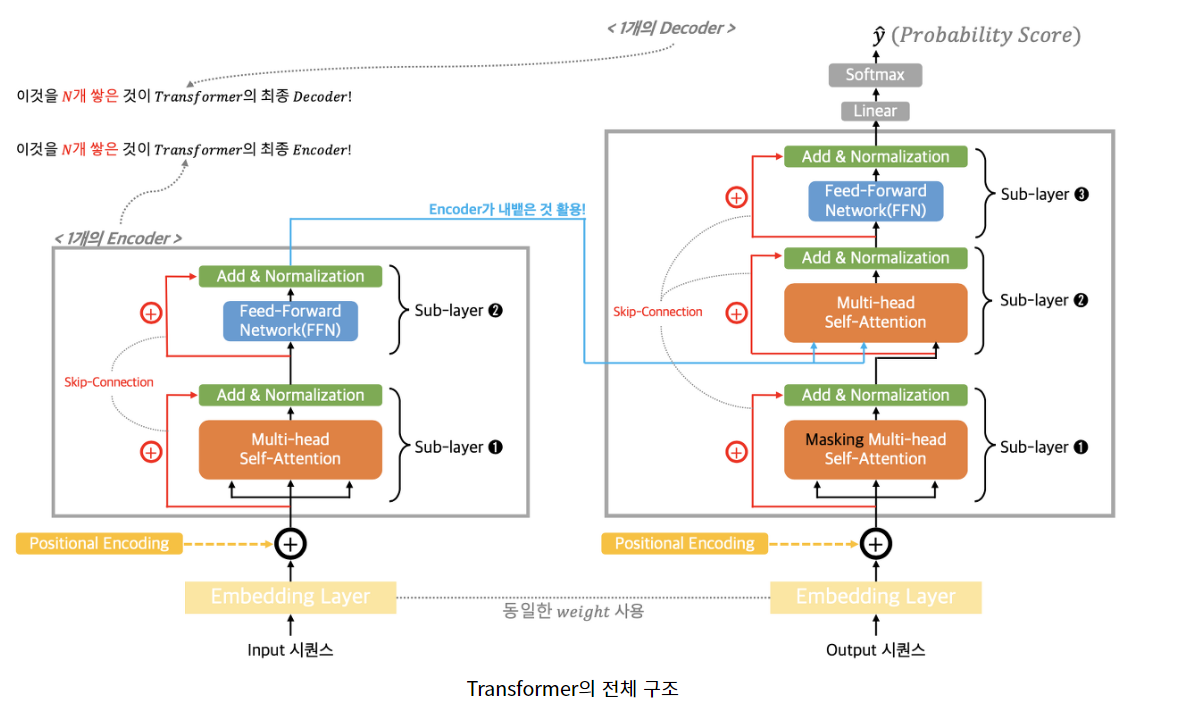

##### Multi-head Self-Attention(멀티-헤드 셀프-어텐션) 계층

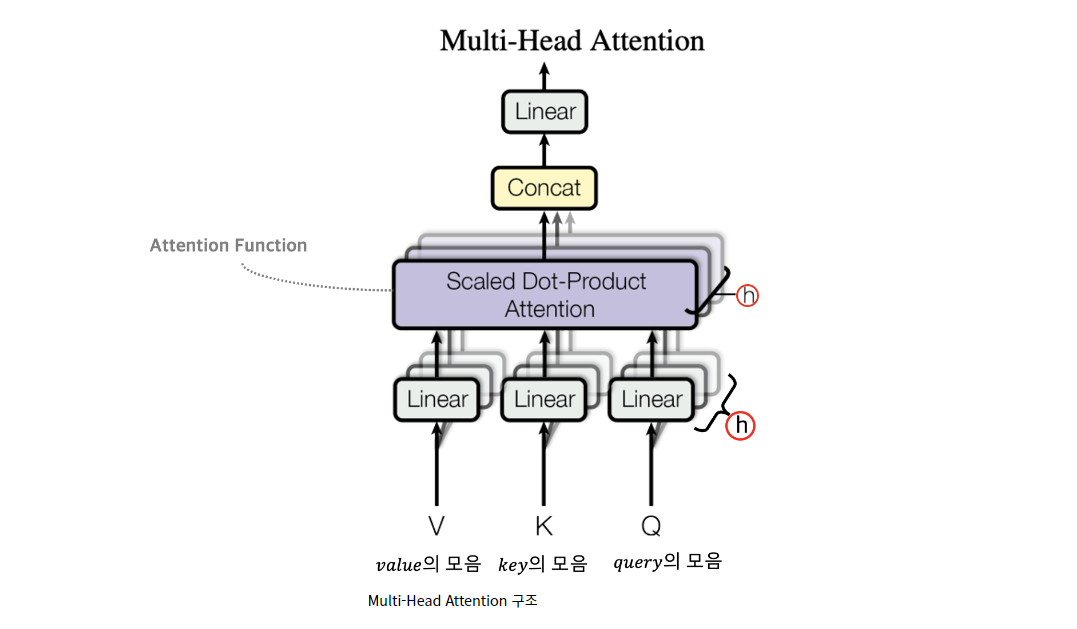

- 'Scaled Dot-Product Attention' 이라는 어텐션 계층이 '여러개'로 구성
- '여러개'는 하이퍼파라미터로서 사용자가 임의대로 설정할 수 있는 ℎ
- 논문에서는 이를 8로 설정해 8개의 Scaled Dot-Product Attention으로 구성 => 논문(Attention Function)

#### 가중치 계산
- Scaled Dot-Product Attention은 V, K, Q 라는 것을 입력
    - V, K, Q: value, key, query의 모음(집합)
    - 입력 시퀀스 또는 출력 시퀀스 내의 토큰 개수 만큼의 value, key, query 를 모아서 한번에 처리

- Scaled Dot-Product Attention 구조 내부
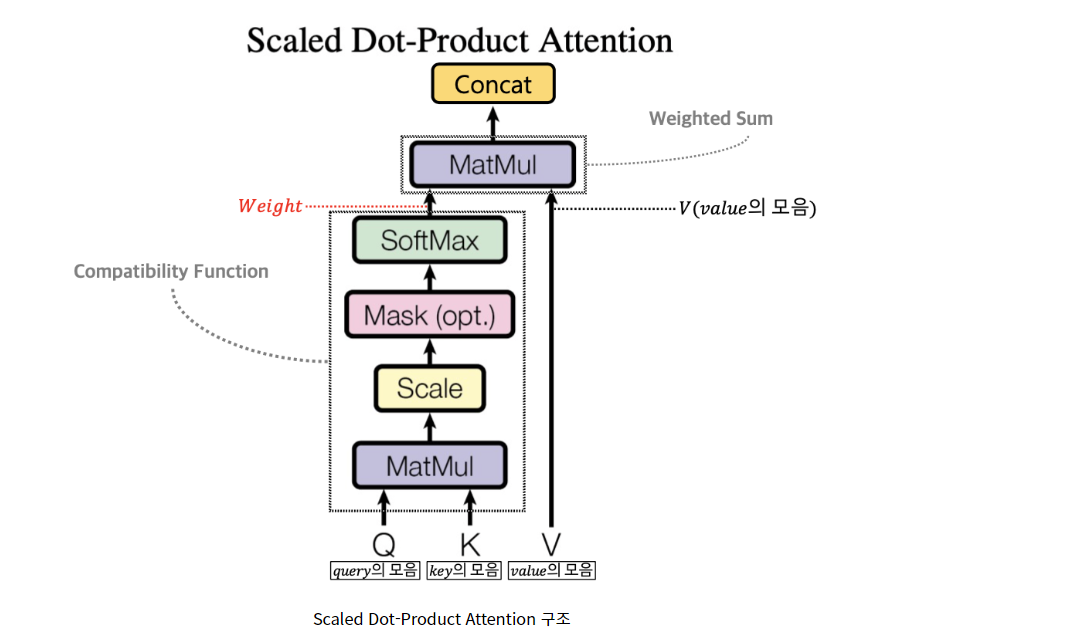

- Scaled Dot-Product Attention 구조
    - Compatibility Function
    - Weighted Sum
- Compatibility Function
    - V 에 부여할 가중치(Weight)를 계산하는 부분
    - query 의 모음인 Q 와 key의 모음인 K를 입력으로 받아서 [Matmul ➜ Scale ➜ Mask(Optional) ➜ Softmax] 연산과정 
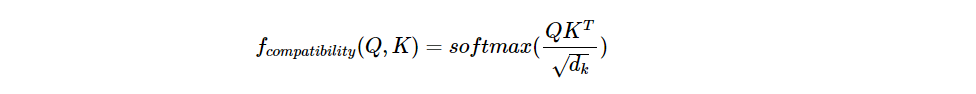

### Point-wise Feed-Forward Network(FFN)
- Multi-Head Self-Attention 계층에서 흘러나온 값을 입력으로 받는 것
- Relu 활성함수를 활용한 선형회귀식을 활용
- 수식 => FFN(x)=max(0, xW1 + b1)W2 + b2
    - max()=> Ralu 활성함수 활용
- FFN을 입력 또는 출력 시퀀스 내의 모든 포지션의 토큰들에 대해 적용
- 매번 적용하는 FFN은 서로 다른 파라미터를 사용



### Add & Normalization 계층
- Add는 Skip(Residual) Connection을 의미
- Skip Connection을 사용하는 이유
    - '덧셈' 연산의 역전파 시 기울기를 건드리지 않고 그대로 흘려보내는 특성 때문에 기울기 소실, 폭발 문제를 막을 수 있기 때문
- Normalization 계층은 출력값들의 분포를 인위적으로 표준정규분포 형태로 만들어 주는 것

### Positional Encoding
- [입력 또는 출력 시퀀스 ➜ Embedding Layer]로 나온 이후에 취해주는 Positional Encoding 기법
- 트랜스포머 모델에도 입력, 출력 시퀀스 내부의 위치(Position)적인 정보를 제공
    - Sin, Cos 함수를 활용하면 모델이 토큰들 간에 상대적인 위치를 쉽게 학습할 것이라고 가정
- Positional Encoding은 차원 수가 dmodel 인데, 이는 Embedding Layer 벡터의 차원 수와 동일한 것을 의미 

### Transformer의 Self-Attention으로 얻은 효과
1. 하나의 레이어 당 전체 연산 복잡도(Computational Complexity)를 줄일 수 있다(병렬 처리 연산의 양을 대폭 늘림)
2. 시퀀스 변환에서의 핵심인 '장기간 의존성(Long-range Dependency)'을 다른 모델에 비해 잘 학습
3. '어텐션' 이라는 가중치를 시각화 하여 토큰들 간의 대응관계를 눈으로 직접 확인